# What annoys each part of Toronto?

An exploratory analysis of Toronto 311 service requests, asking whether different parts of the city report different kinds of problems.

**Analysis period:** January 1, 2026 – June 30, 2026  
**Unit of observation:** one 311 service request  
**Geographic unit:** Toronto's current 25 wards

> This notebook is the reproducible analysis behind the accompanying visual story. The goal is descriptive, not causal: a 311 request reflects something a resident reported to the City, not necessarily the true prevalence of an underlying problem.

## 1. Setup

### Data source

This analysis uses the City of Toronto's **311 Service Requests – Customer Initiated** open-data records.

The raw CSV is intentionally kept outside the notebook. For local execution, place the downloaded file at:

`data/SR2026.csv`

The raw file is not committed to GitHub

In [1]:
from pathlib import Path
import csv

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("data/SR2026.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Download the Toronto 311 data and place the CSV at that path."
    )

## 2. Load and clean the raw data

The source file contains a small number of malformed rows where commas inside the `Division` or `Section` values are not quoted. Rather than silently dropping those rows, the parser below explicitly repairs the two known row structures and raises an error if an unexpected structure appears.

This makes the cleaning step auditable and prevents a parser setting such as `on_bad_lines="skip"` from silently changing the analysis.

In [2]:
EXPECTED_COLUMNS = [
    "Creation Date",
    "Status",
    "First 3 Chars of Postal Code",
    "Intersection Street 1",
    "Intersection Street 2",
    "Ward",
    "Service Request Type",
    "Division",
    "Section",
]

rows = []
row_lengths = {}

with DATA_PATH.open("r", encoding="cp1252", newline="") as f:
    reader = csv.reader(f)
    header = next(reader)

    for row_number, row in enumerate(reader, start=2):
        row_lengths[len(row)] = row_lengths.get(len(row), 0) + 1

        if len(row) == 9:
            cleaned_row = row

        elif len(row) == 10 and row[7] == "Environment":
            # Unquoted comma split "Environment, Climate & Forestry"
            cleaned_row = row[:7] + [
                f"{row[7]},{row[8]}",
                row[9],
            ]

        elif (
            len(row) == 10
            and row[7] == "Solid Waste Management Services"
            and row[8] == "Transfer"
        ):
            # Unquoted comma split "Transfer, Disposal & Operations"
            cleaned_row = row[:8] + [
                f"{row[8]},{row[9]}",
            ]

        else:
            raise ValueError(
                f"Unexpected row structure at source row {row_number}: "
                f"{len(row)} fields"
            )

        rows.append(cleaned_row)

df = pd.DataFrame(rows, columns=EXPECTED_COLUMNS)

print(f"Loaded {len(df):,} records.")
print(f"Source row structures: {row_lengths}")

Loaded 289,170 records.
Source row structures: {9: 272036, 10: 17134}


In [3]:
# Standardize types
df["Creation Date"] = pd.to_datetime(df["Creation Date"], errors="coerce")

# Remove administrative 311 service requests.
# These are not neighbourhood complaint/request types for this analysis.
df = df[df["Division"] != "311"].copy()

# Request type is required for complaint-level analysis.
missing_request_types = df["Service Request Type"].isna().sum()
df = df.dropna(subset=["Service Request Type"]).copy()

# Keep only records that belong to the current 25-ward geography.
df["Ward Number"] = pd.to_numeric(
    df["Ward"].str.extract(r"\((\d{2})\)")[0],
    errors="coerce"
).astype("Int64")

df["Ward Name"] = df["Ward"].str.replace(
    r"\s*\(\d{2}\)$", "", regex=True
)

analysis_df = df[df["Ward Number"].between(1, 25)].copy()

print(f"Records after cleaning: {len(analysis_df):,}")
print(f"Records excluded for missing/unknown ward: {len(df) - len(analysis_df):,}")
print(f"Wards represented: {analysis_df['Ward Number'].nunique()}")
print(
    f"Date range: {analysis_df['Creation Date'].min():%Y-%m-%d} "
    f"to {analysis_df['Creation Date'].max():%Y-%m-%d}"
)
print(f"Missing request types removed: {missing_request_types:,}")

Records after cleaning: 286,498
Records excluded for missing/unknown ward: 6
Wards represented: 25
Date range: 2026-01-01 to 2026-06-30
Missing request types removed: 0


In [4]:
# Basic QA checks
#Before analysis, I verify that all 25 Toronto wards are represented and that the fields required for the analysis contain no missing values.

assert analysis_df["Ward Number"].nunique() == 25
assert analysis_df["Creation Date"].notna().all()
assert analysis_df["Service Request Type"].notna().all()

print("QA checks passed.")

QA checks passed.


## 3. What gets reported most often?

First, I look at **frequency**: which service-request types account for the most 311 records citywide?

This is deliberately separate from the later **distinctiveness** analysis. A complaint can be extremely common across Toronto without being especially characteristic of any one ward.

In [5]:
complaint_counts = (
    analysis_df["Service Request Type"]
    .value_counts()
    .rename_axis("Complaint")
    .reset_index(name="Count")
)

complaint_counts["Share"] = complaint_counts["Count"] / len(analysis_df)

display(complaint_counts.head(10))

,Complaint,Count,Share
0,Road Pothole / Road Damage,21505,0.075062
1,Sidewalk Snow Clearing Required,11262,0.039309
2,Road Plowing Request,10933,0.038161
3,Property Standards and Maintenance Violations,9424,0.032894
4,Residential Bin Lid Damaged,9141,0.031906
5,Driveway Blocked By Plowed Snowbank,6956,0.024279
6,Injured - Wildlife,5975,0.020855
7,General Pruning,5162,0.018018
8,Pick up Dead Wildlife,4801,0.016758
9,Tree Emergency Clean-Up,4387,0.015312


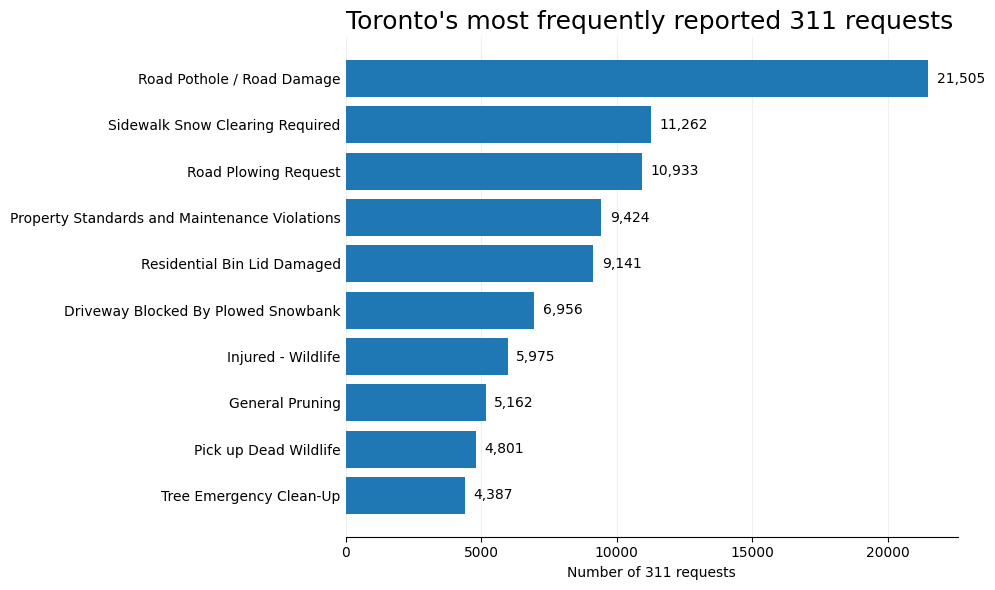

In [6]:
top_10 = complaint_counts.head(10).sort_values("Count")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_10["Complaint"],
    top_10["Count"],
)

for bar, count in zip(bars, top_10["Count"]):
    ax.text(
        count + top_10["Count"].max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=10,
    )

ax.set_title("Toronto's most frequently reported 311 requests", loc="left", fontsize=18)
ax.set_xlabel("Number of 311 requests")
ax.set_ylabel("")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 4. Top complaint vs. signature complaint

Two different questions drive the rest of the analysis:

**Top complaint:** What request type has the largest number of records in a ward?

**Signature complaint:** What request type is *more prominent in a ward than it is across Toronto overall*?

For distinctiveness, I use:

$$
\mathrm{Distinctiveness}
=
\frac{\mathrm{Share\ of\ the\ complaint\ within\ the\ ward}}
{\mathrm{Share\ of\ that\ complaint\ citywide}}
$$

A value of **1.0×** means the complaint has the same share locally as it does citywide.

A value above **1.0×** means the complaint is more prominent locally.

In [7]:
area_totals = (
    analysis_df
    .groupby("Ward Number")
    .size()
    .rename("Ward Total")
)

area_complaints = (
    analysis_df
    .groupby(["Ward Number", "Ward Name", "Service Request Type"])
    .size()
    .rename("Count")
    .reset_index()
)

area_complaints = area_complaints.merge(
    area_totals,
    on="Ward Number",
    how="left",
)

area_complaints["Ward Share"] = (
    area_complaints["Count"] / area_complaints["Ward Total"]
)

city_share = (
    analysis_df["Service Request Type"]
    .value_counts(normalize=True)
    .rename("City Share")
)

area_complaints = area_complaints.merge(
    city_share,
    left_on="Service Request Type",
    right_index=True,
    how="left",
)

area_complaints["Distinctiveness"] = (
    area_complaints["Ward Share"] / area_complaints["City Share"]
)

top_complaint = (
    area_complaints
    .sort_values(["Ward Number", "Count"], ascending=[True, False])
    .drop_duplicates("Ward Number")
    .reset_index(drop=True)
)

# To avoid tiny counts dominating the signature calculation:
MIN_SIGNATURE_COUNT = 50

signature_complaints = (
    area_complaints[area_complaints["Count"] >= MIN_SIGNATURE_COUNT]
    .sort_values(
        ["Ward Number", "Distinctiveness"],
        ascending=[True, False],
    )
    .drop_duplicates("Ward Number")
    .reset_index(drop=True)
)

display(
    signature_complaints[
        [
            "Ward Number",
            "Ward Name",
            "Service Request Type",
            "Count",
            "Ward Share",
            "City Share",
            "Distinctiveness",
        ]
    ]
)

,Ward Number,Ward Name,Service Request Type,Count,Ward Share,City Share,Distinctiveness
0,1,Etobicoke North,Residential Bin Wheel Damaged,84,0.009988,0.002740,3.645316
1,2,Etobicoke Centre,Culverts - Blocked,58,0.004652,0.000548,8.489615
2,3,Etobicoke-Lakeshore,Culverts - Blocked,51,0.003555,0.000548,6.487260
3,4,Parkdale-High Park,Res / Garbage / Multiple Addresses Not Picked Up,173,0.012291,0.003410,3.604332
4,5,York South-Weston,Sidewalk Snow Clearing Required,981,0.080648,0.039309,2.051628
5,6,York Centre,Moving Motor Vehicle Noise,904,0.080924,0.004579,17.671123
6,7,Humber River-Black Creek,Waste Set Out - Wrong Location / Time/ Day,90,0.012212,0.005581,2.188004
7,8,Eglinton-Lawrence,Restoration Related,55,0.003812,0.001731,2.202047
8,9,Davenport,Laneway Needs Salting,199,0.011849,0.003187,3.718124
9,10,Spadina-Fort York,Road - Graffiti Complaint,89,0.007609,0.000956,7.955849


## 5. Finding 1 
## Moving motor vehicle noise

The signature analysis surfaces an unusually strong result in **Ward 6**. I then drill down into the underlying records to ask whether the pattern comes from many locations or a single hotspot.

In [8]:
TARGET_NOISE = "Moving Motor Vehicle Noise"

vehicle_noise = analysis_df[
    analysis_df["Service Request Type"] == TARGET_NOISE
].copy()

ward_6_noise = vehicle_noise[vehicle_noise["Ward Number"] == 6]

ward_6_total = (analysis_df["Ward Number"] == 6).sum()
city_noise_total = len(vehicle_noise)

ward_6_noise_share = len(ward_6_noise) / ward_6_total
city_noise_share = city_noise_total / len(analysis_df)

noise_distinctiveness = ward_6_noise_share / city_noise_share

print(f"Ward 6 motor vehicle noise requests: {len(ward_6_noise):,}")
print(f"Citywide motor vehicle noise requests: {city_noise_total:,}")
print(f"Ward 6 distinctiveness: {noise_distinctiveness:.1f}×")

Ward 6 motor vehicle noise requests: 904
Citywide motor vehicle noise requests: 1,312
Ward 6 distinctiveness: 17.7×


In [9]:
vehicle_noise_intersections = (
    vehicle_noise
    .groupby(
        [
            "First 3 Chars of Postal Code",
            "Intersection Street 1",
            "Intersection Street 2",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

top_noise_location = vehicle_noise_intersections.iloc[0]

top_street_1 = top_noise_location["Intersection Street 1"]
top_street_2 = top_noise_location["Intersection Street 2"]
top_intersection_count = int(top_noise_location["Count"])

ward_6_hotspot = vehicle_noise[
    (vehicle_noise["Ward Number"] == 6)
    & (vehicle_noise["Intersection Street 1"] == top_street_1)
    & (vehicle_noise["Intersection Street 2"] == top_street_2)
]

ward_6_hotspot_share = len(ward_6_hotspot) / len(ward_6_noise)

print(
    f"Top intersection: {top_street_1} × {top_street_2}"
)
print(
    f"Requests at that intersection: {top_intersection_count:,}"
)
print(
    f"Share of Ward 6 motor vehicle noise requests: "
    f"{ward_6_hotspot_share:.1%}"
)

Top intersection: Bathurst St × Canyon Ave
Requests at that intersection: 836
Share of Ward 6 motor vehicle noise requests: 92.5%


In [10]:
# Check whether the hotspot is concentrated in one reporting period.
ward_6_hotspot = ward_6_hotspot.copy()
ward_6_hotspot["Month"] = (
    pd.to_datetime(ward_6_hotspot["Creation Date"])
    .dt.to_period("M")
)

monthly_hotspot = (
    ward_6_hotspot["Month"]
    .value_counts()
    .sort_index()
)

display(monthly_hotspot.rename("Requests").to_frame())

,Requests
Month,
2026-01,56
2026-02,69
2026-03,72
2026-04,190
2026-05,223
2026-06,226


## 6. Finding 2 
## Graffiti as an inner-Toronto pattern

For graffiti, I combine several graffiti-related request types and compare each ward's **graffiti share** with Toronto's citywide graffiti share.

This asks a different question from raw counts: *is graffiti unusually prominent in a ward's overall 311 request mix?*

In [11]:
graffiti = analysis_df[
    analysis_df["Service Request Type"]
    .str.contains("Graffiti", case=False, na=False)
].copy()

graffiti_counts = (
    graffiti.groupby("Ward Number")
    .size()
    .rename("Graffiti Count")
)

graffiti_analysis = (
    area_totals
    .rename("Ward Total")
    .to_frame()
    .join(graffiti_counts, how="left")
    .fillna({"Graffiti Count": 0})
)

graffiti_analysis["Ward Graffiti Share"] = (
    graffiti_analysis["Graffiti Count"]
    / graffiti_analysis["Ward Total"]
)

city_graffiti_share = len(graffiti) / len(analysis_df)

graffiti_analysis["Graffiti Distinctiveness"] = (
    graffiti_analysis["Ward Graffiti Share"]
    / city_graffiti_share
)

graffiti_analysis = graffiti_analysis.merge(
    analysis_df[["Ward Number", "Ward Name"]].drop_duplicates(),
    on="Ward Number",
    how="left",
)

graffiti_analysis = graffiti_analysis.sort_values(
    "Graffiti Distinctiveness",
    ascending=False,
)

display(
    graffiti_analysis[
        [
            "Ward Number",
            "Ward Name",
            "Graffiti Count",
            "Ward Graffiti Share",
            "Graffiti Distinctiveness",
        ]
    ].head(15)
)

,Ward Number,Ward Name,Graffiti Count,Ward Graffiti Share,Graffiti Distinctiveness
10,11,University-Rosedale,1095,0.070346,4.457837
9,10,Spadina-Fort York,665,0.056852,3.602751
12,13,Toronto Centre,552,0.049010,3.105790
8,9,Davenport,477,0.028401,1.799805
13,14,Toronto-Danforth,393,0.022158,1.404184
3,4,Parkdale-High Park,287,0.020391,1.292173
18,19,Beaches-East York,274,0.017859,1.131763
11,12,Toronto-St. Paul's,166,0.011758,0.745113
17,18,Willowdale,83,0.009856,0.624599
7,8,Eglinton-Lawrence,136,0.009427,0.597379


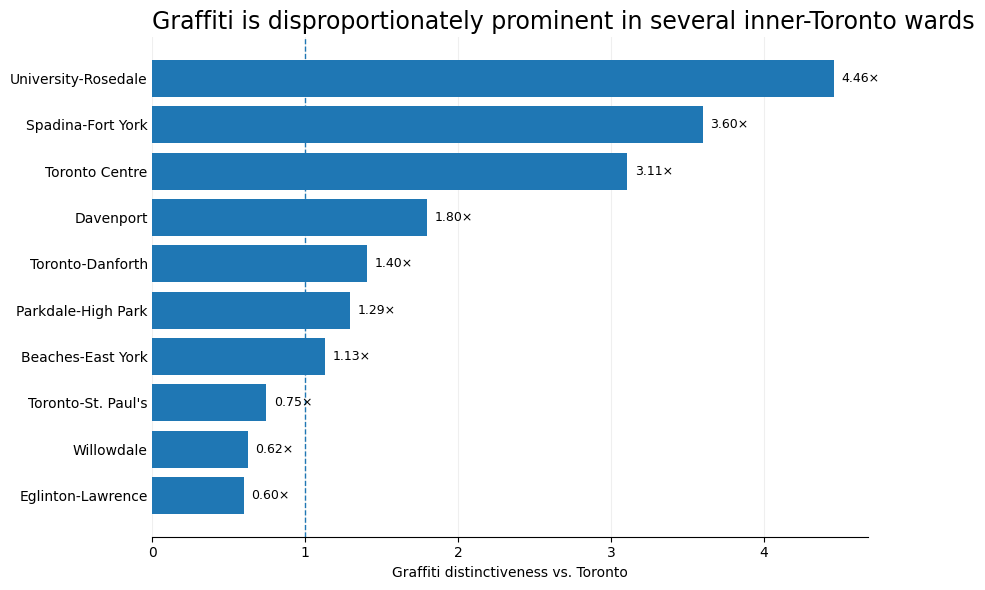

In [12]:
plot_graffiti = graffiti_analysis.head(10).sort_values(
    "Graffiti Distinctiveness"
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    plot_graffiti["Ward Name"],
    plot_graffiti["Graffiti Distinctiveness"],
)

for bar, value in zip(
    bars,
    plot_graffiti["Graffiti Distinctiveness"],
):
    ax.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}×",
        va="center",
        fontsize=9,
    )

ax.axvline(1, linestyle="--", linewidth=1)
ax.set_title(
    "Graffiti is disproportionately prominent in several inner-Toronto wards",
    loc="left",
    fontsize=17,
)
ax.set_xlabel("Graffiti distinctiveness vs. Toronto")
ax.set_ylabel("")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 7. Finding 3 
## Potholes dominate by frequency

Potholes tell a different story from the signature analysis.

They are the most frequently reported request type across Toronto, and they remain the **#1 complaint in most individual wards**.

This is why the project separates *frequency* from *distinctiveness*: potholes are common everywhere, while complaints such as motor vehicle noise or graffiti can be unusually prominent in particular places.

In [13]:
TARGET_POTHOLE = "Road Pothole / Road Damage"

pothole_is_top = (
    top_complaint["Service Request Type"] == TARGET_POTHOLE
)

pothole_ward_count = int(pothole_is_top.sum())
total_wards = int(top_complaint["Ward Number"].nunique())

citywide_pothole_count = int(
    complaint_counts.loc[
        complaint_counts["Complaint"] == TARGET_POTHOLE,
        "Count",
    ].iloc[0]
)

print(
    f"{TARGET_POTHOLE}: {citywide_pothole_count:,} requests citywide"
)
print(
    f"{TARGET_POTHOLE} ranked #1 in "
    f"{pothole_ward_count} of {total_wards} wards."
)

Road Pothole / Road Damage: 21,505 requests citywide
Road Pothole / Road Damage ranked #1 in 18 of 25 wards.


In [14]:
pothole_ward_summary = top_complaint[
    ["Ward Number", "Ward Name", "Service Request Type", "Count"]
].copy()

pothole_ward_summary["Is Pothole #1"] = (
    pothole_ward_summary["Service Request Type"] == TARGET_POTHOLE
)

display(pothole_ward_summary)

,Ward Number,Ward Name,Service Request Type,Count,Is Pothole #1
0,1,Etobicoke North,Road Pothole / Road Damage,818,True
1,2,Etobicoke Centre,Road Pothole / Road Damage,957,True
2,3,Etobicoke-Lakeshore,Road Pothole / Road Damage,1346,True
3,4,Parkdale-High Park,Sidewalk Snow Clearing Required,756,False
4,5,York South-Weston,Sidewalk Snow Clearing Required,981,False
5,6,York Centre,Road Pothole / Road Damage,1437,True
6,7,Humber River-Black Creek,Road Pothole / Road Damage,917,True
7,8,Eglinton-Lawrence,Road Pothole / Road Damage,1108,True
8,9,Davenport,Road Plowing Request,1052,False
9,10,Spadina-Fort York,Road Pothole / Road Damage,541,True


## 8. Export analysis tables for Tableau

The final export contains the fields needed to reproduce the ward-level maps used in the visual story.

The notebook does not manually assign the findings to wards; the fields below are derived from the cleaned request-level data.

In [15]:
signature_map = (
    signature_complaints
    .set_index("Ward Number")["Service Request Type"]
)

signature_distinctiveness_map = (
    signature_complaints
    .set_index("Ward Number")["Distinctiveness"]
)

graffiti_distinctiveness_map = (
    graffiti_analysis
    .set_index("Ward Number")["Graffiti Distinctiveness"]
)

top_complaint_map = (
    top_complaint
    .set_index("Ward Number")["Service Request Type"]
)

export_df = analysis_df.copy()

export_df["Signature Complaint"] = (
    export_df["Ward Number"].map(signature_map)
)

export_df["Signature Distinctiveness"] = (
    export_df["Ward Number"].map(signature_distinctiveness_map)
)

export_df["Graffiti Distinctiveness"] = (
    export_df["Ward Number"].map(graffiti_distinctiveness_map)
)

export_df["Top Complaint"] = (
    export_df["Ward Number"].map(top_complaint_map)
)

output_path = OUTPUT_DIR / "toronto_311_clean.csv"

export_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8",
)

print(f"Saved: {output_path}")

Saved: outputs\toronto_311_clean.csv


## 9. Limitations and interpretation

- **311 requests measure reporting behaviour, not the true prevalence of problems.** Residents differ in what they notice and report, and reporting behaviour can vary geographically.
- **The open dataset is not a complete record of all 311 interactions.** The City notes that the open 311 dataset represents only a subset of total requests. Source: https://open.toronto.ca/dataset/311-service-requests-customer-initiated/
- **Ward-level comparisons are descriptive.** A high distinctiveness score does not imply that the ward has a causal relationship with that complaint.
- **Small counts can create unstable ratios.** The signature-complaint calculation therefore requires at least `MIN_SIGNATURE_COUNT` requests before a complaint can be selected as a signature.
- **The study period is limited to the records in the supplied 2026 file.** Results should not be interpreted as year-round or long-term trends.

## Takeaway

The analysis reveals three different ways of looking at Toronto's 311 complaints:

1. **Frequency:** potholes are the city's most common request and the #1 complaint in most wards.
2. **Distinctiveness:** some complaints are unusually prominent in specific places, such as moving motor vehicle noise in Ward 6.
3. **Spatial pattern:** graffiti's distinctiveness is elevated across several neighbouring inner-Toronto wards rather than being isolated to one ward.

Together, these measures show why asking *"what do people complain about?"* is different from asking *"what is distinctive about each part of the city?"*